In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
# For manual stuff (added manually)

sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\multiple_lines_phd\FLAMES_lagoon\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\multiple_lines_phd\FLAMES_lagoon")

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params


# Loading files

In [3]:
H_file_name = "FLA-M8-H"
#O_file_name = "FLA-Car-O"
N_file_name = "FLA-M8-N"
S_file_name = "FLA-M8-S"

labels = ['H', 'N', 'S']

In [4]:
H_ = results_comp.load_line_bundle(H_file_name, "H_line", MAPS_DIR, read_header=True)
#O_ = results_comp.load_line_bundle(O_file_name, "O_line", MAPS_DIR, read_header=True)
S_ = results_comp.load_line_bundle(S_file_name, "S_line", MAPS_DIR, read_header=True)
N_ = results_comp.load_line_bundle(N_file_name, "N_line", MAPS_DIR, read_header=True)


print(H_['obs']['V_mean'].var())
#print(O_['obs']['V_mean'].var())
print(N_['obs']['V_mean'].var())
print(S_['obs']['V_mean'].var())


7.526433868794324
10.468659374077292
11.072776813938345


In [5]:
obs_var = [H_['obs']['V_mean'].var(), N_['obs']['V_mean'].var(), S_['obs']['V_mean'].var()]
obs_var

[7.526433868794324, 10.468659374077292, 11.072776813938345]

In [6]:
obs_std = [H_['obs']['V_mean'].std(), N_['obs']['V_mean'].std(), S_['obs']['V_mean'].std()]
obs_std

[2.7434346846233324, 3.2355307716165043, 3.3275782205589617]

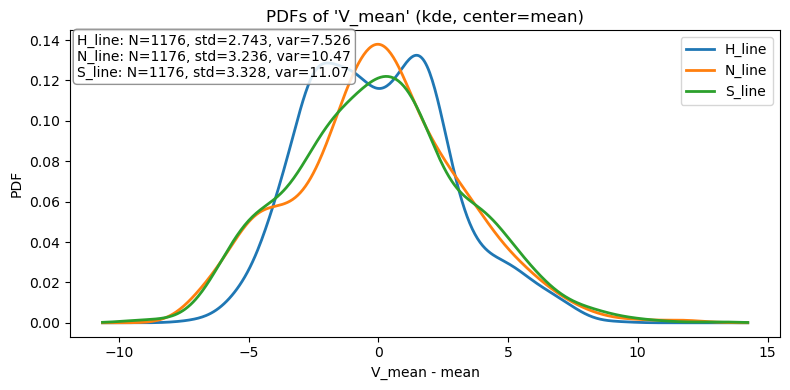

In [7]:
import list_maps_plots

dfs = {"H_line": H_['obs'], "N_line": N_['obs'], "S_line": S_['obs']}
fig, ax = list_maps_plots.plot_list_pdfs(dfs, col="V_mean", center="mean", method="kde")

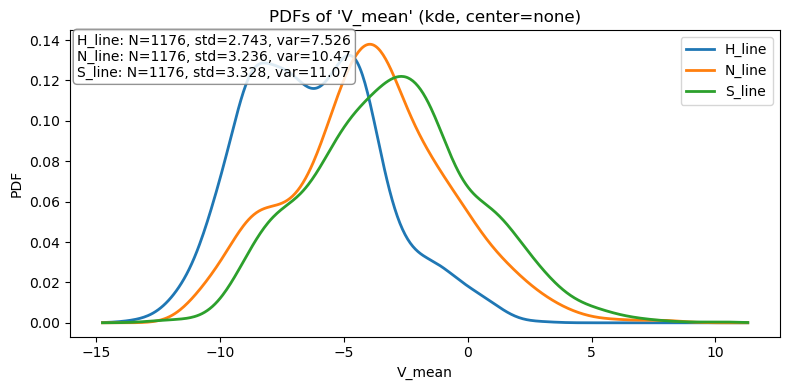

In [8]:
fig, ax = list_maps_plots.plot_list_pdfs(dfs, col="V_mean", method="kde")

# Load lmfit results

In [9]:
# H
name = H_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

H_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [10]:
# N
name = N_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [11]:
# S
name = S_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

S_line = ci_results_compiler.ci_results_compiler(fit_Br)

# Plots lmfit parameter comparison

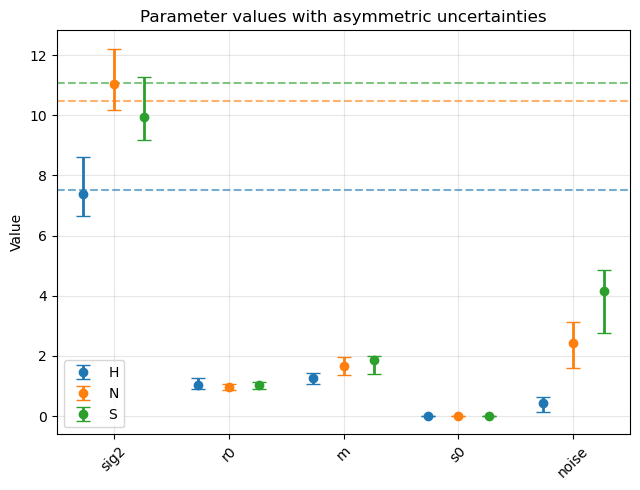

In [12]:
# Modify _line matching loaded data

plot_fit_params.plot_param_comp_obs(H_line, N_line, S_line, labels=labels, obs=obs_var)

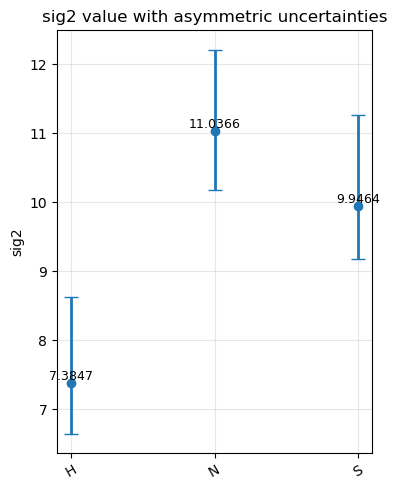

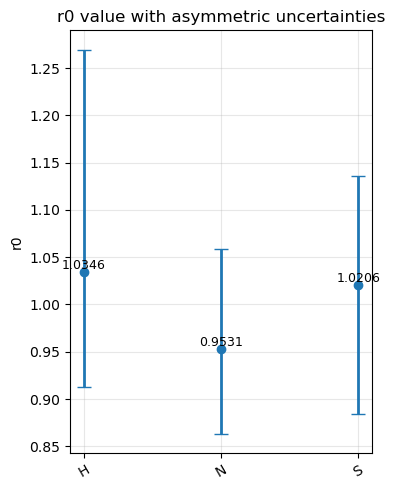

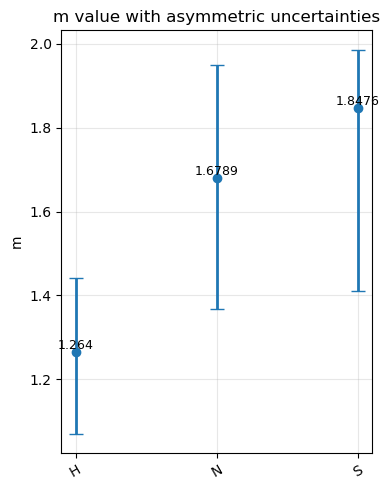

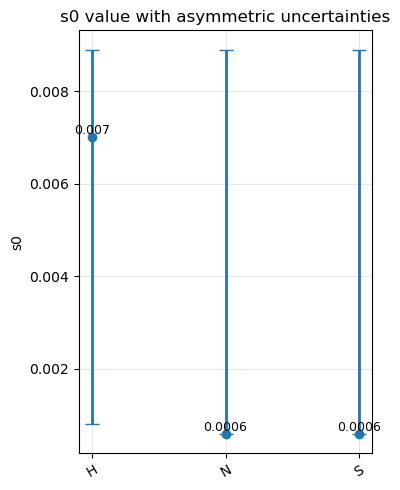

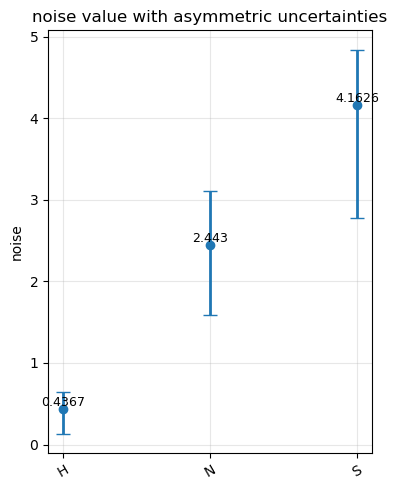

In [13]:
# Modify _line matching loaded data

plot_fit_params.plot_param(H_line, N_line, S_line, labels=labels,
                                decimals=4)
